## **Menganalisis Perbandingan Algoritma Support Vector Machine (SVM), Extremely Randomized Trees (Extra Trees), dan eXtreme Gradient Boosting (XGBoost) untuk Prediksi Kematian Pasien ICU menggunakan Data Klinis dengan Missing Tinggi.**

### SUMBER DATA:

Dataset ini bersumber dari Kaggle: WiDS Datathon 2020. Dataset yang digunakan adalah file training_v2.csv yang berisi sekitar 91.713 data pasien (encounters) di Intensive Care Unit (ICU). Dataset ini memuat berbagai informasi seperti data demografis, kondisi klinis, tanda vital, serta hasil pemeriksaan medis pasien.

Target yang diprediksi adalah hospital_death, yaitu apakah pasien meninggal (1) atau bertahan hidup (0). Karena target berupa kategori biner, maka permasalahan ini termasuk dalam klasifikasi.

### 1. Data Understanding

Pada tahap ini dilakukan pemahaman terhadap dataset yang digunakan. Pertama, dataset dibaca dari file training_v2.csv, lalu dilakukan pengambilan sebanyak 5000 data secara stratified berdasarkan target hospital_death agar distribusi kelas tetap terjaga.

Selanjutnya dilakukan eksplorasi awal data dengan melihat ukuran dataset, distribusi kelas, tipe data, statistik deskriptif, serta jumlah missing values. Tahap ini bertujuan untuk memahami kondisi data sebelum masuk ke proses preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('training_v2.csv')

# ambil 5000 data (stratified)
df = df.groupby('hospital_death', group_keys=False).apply(
    lambda x: x.sample(frac=5000/len(df), random_state=42)
)

print(df.shape)
print(df['hospital_death'].value_counts())

print(df.info())
print(df.describe())
print(df.isnull().sum())

/tmp/ipykernel_820/2492608049.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('hospital_death', group_keys=False).apply(


(5000, 186)
hospital_death
0    4576
1     424
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 43754 to 36219
Columns: 186 entries, encounter_id to apache_2_bodysystem
dtypes: float64(170), int64(8), object(8)
memory usage: 7.1+ MB
None
        encounter_id     patient_id  hospital_id  hospital_death          age  \
count    5000.000000    5000.000000  5000.000000     5000.000000  4756.000000   
mean    65430.358200   65452.997800   108.000000        0.084800    63.013667   
std     37264.109727   37708.053901    48.748892        0.278612    16.685387   
min        37.000000       6.000000     4.000000        0.000000    16.000000   
25%     32980.750000   32916.500000    70.000000        0.000000    53.000000   
50%     65836.000000   65206.000000   112.000000        0.000000    65.000000   
75%     97437.500000   98379.250000   140.000000        0.000000    76.000000   
max    131034.000000  131040.000000   204.000000        1.000000    89.000000 

In [ ]:
print(df.head())

       encounter_id  patient_id  hospital_id  hospital_death   age        bmi  \
43754         92951        3232          100               0  56.0  22.763564   
41160         88500      130122           14               0  28.0  37.028968   
8115          95701       51202          151               0  84.0  29.052951   
35013         31720       77834           70               0  84.0  24.314124   
780          103270        2647           83               0  67.0  23.218414   

       elective_surgery         ethnicity gender  height  ... aids cirrhosis  \
43754                 0         Caucasian      M   180.3  ...  0.0       0.0   
41160                 0         Caucasian      F   162.6  ...  0.0       0.0   
8115                  0         Caucasian      F   139.7  ...  0.0       0.0   
35013                 0  African American      F   166.0  ...  0.0       0.0   
780                   1         Caucasian      M   177.8  ...  0.0       0.0   

       diabetes_mellitus hepatic

### 2. Data Preprocessing

Pada tahap preprocessing dilakukan beberapa proses penting untuk mempersiapkan data. Pertama, dilakukan feature selection dengan memilih fitur-fitur yang dianggap relevan terhadap target hospital_death, sehingga dapat mengurangi noise dan meningkatkan performa model.

Selanjutnya dilakukan penanganan missing values, di mana data numerik diisi menggunakan median dan data kategorikal diisi menggunakan modus. Kemudian dilakukan encoding menggunakan LabelEncoder untuk mengubah data kategorikal menjadi numerik agar dapat diproses oleh algoritma machine learning.

Terakhir, dilakukan feature engineering dengan menambahkan dua fitur baru yaitu risk_mean (rata-rata dari dua probabilitas kematian) dan risk_diff (selisih absolut dari kedua probabilitas tersebut). Fitur baru ini bertujuan untuk memberikan informasi tambahan yang dapat membantu model dalam mengenali pola data.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# FEATURE SELECTION
selected_cols = [
    'age','bmi','height','gender',
    'elective_surgery',
    'diabetes_mellitus',
    'apache_2_bodysystem',
    'apache_3j_bodysystem',
    'glucose_apache',
    'apache_4a_hospital_death_prob',
    'apache_4a_icu_death_prob',
    'd1_sysbp_min',
    'd1_mbp_min',
    'd1_resprate_max',
    'd1_temp_max',
    'd1_heartrate_max',
    'hospital_death'
]

df = df[selected_cols]

# PREPROCESSING

# missing value
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# encoding
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# FEATURE ENGINEERING
df['risk_mean'] = (df['apache_4a_icu_death_prob'] + df['apache_4a_hospital_death_prob']) / 2
df['risk_diff'] = abs(df['apache_4a_icu_death_prob'] - df['apache_4a_hospital_death_prob'])

print(df.isnull().sum())

print("\nJumlah data yang duplikat :")
print(df.duplicated().sum())

age                              0
bmi                              0
height                           0
gender                           0
elective_surgery                 0
diabetes_mellitus                0
apache_2_bodysystem              0
apache_3j_bodysystem             0
glucose_apache                   0
apache_4a_hospital_death_prob    0
apache_4a_icu_death_prob         0
d1_sysbp_min                     0
d1_mbp_min                       0
d1_resprate_max                  0
d1_temp_max                      0
d1_heartrate_max                 0
hospital_death                   0
risk_mean                        0
risk_diff                        0
dtype: int64

Jumlah data yang duplikat :
0


### 3. Data Transformation (Scaling)

Pada tahap ini dilakukan standarisasi data menggunakan StandardScaler agar semua fitur memiliki skala yang sama. Hal ini penting untuk meningkatkan performa model, terutama pada algoritma yang sensitif terhadap perbedaan skala data seperti SVM.

In [ ]:
from sklearn.preprocessing import StandardScaler

# SCALING
X = df.drop("hospital_death", axis=1)
y = df["hospital_death"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 4. Exploratory Data Analysis (EDA)

Pada tahap EDA dilakukan eksplorasi data menggunakan visualisasi untuk memahami pola dalam dataset. Pertama, ditampilkan distribusi target hospital_death untuk melihat keseimbangan kelas. Selanjutnya, distribusi beberapa fitur numerik divisualisasikan untuk memahami sebaran data.

Selain itu, dilakukan deteksi outlier menggunakan boxplot. Outlier tidak dihapus karena dalam konteks data medis, nilai ekstrem dapat merepresentasikan kondisi pasien yang kritis dan tetap memiliki makna penting. Terakhir, dilakukan analisis korelasi antar fitur menggunakan heatmap yang dilengkapi dengan nilai korelasi pada setiap pasangan fitur, sehingga hubungan antar variabel dapat terlihat lebih jelas.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

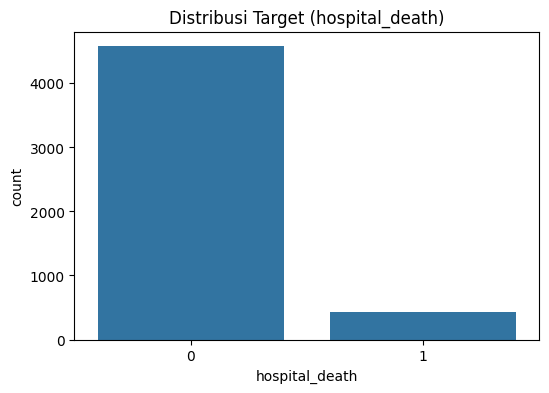

In [ ]:
# DISTRIBUSI TARGET
plt.figure(figsize=(6,4))
sns.countplot(x=df['hospital_death'])
plt.title("Distribusi Target (hospital_death)")
plt.show()

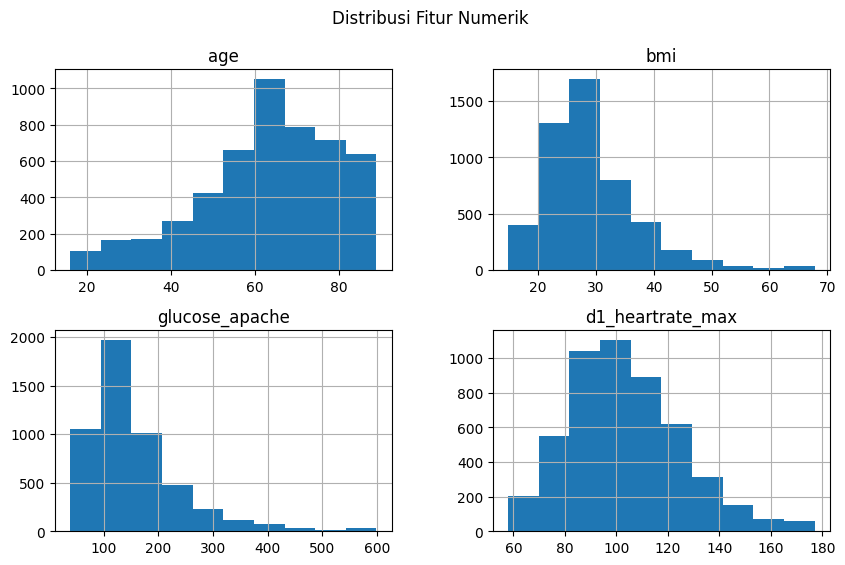

In [ ]:
# DISTRIBUSI FITUR NUMERIK
df[['age','bmi','glucose_apache','d1_heartrate_max']].hist(figsize=(10,6))
plt.suptitle("Distribusi Fitur Numerik")
plt.show()


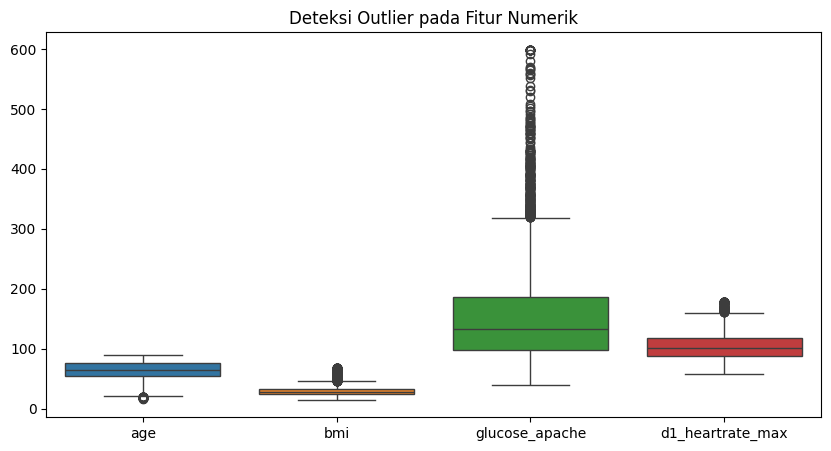

In [ ]:
# =========================================
# OUTLIER DETECTION (BOXPLOT)
# =========================================
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['age','bmi','glucose_apache', 'd1_heartrate_max']])
plt.title("Deteksi Outlier pada Fitur Numerik")
plt.show()

Berdasarkan visualisasi boxplot diatas, ditemukan adanya outlier pada beberapa fitur seperti BMI, glucose_apache, dan d1_heartrate_max. Namun, outlier tersebut tidak dihapus karena masih berada dalam rentang nilai yang memungkinkan secara medis, terutama dalam konteks pasien ICU. Nilai ekstrem tersebut justru merepresentasikan kondisi pasien yang kritis sehingga tetap dipertahankan dalam proses pemodelan

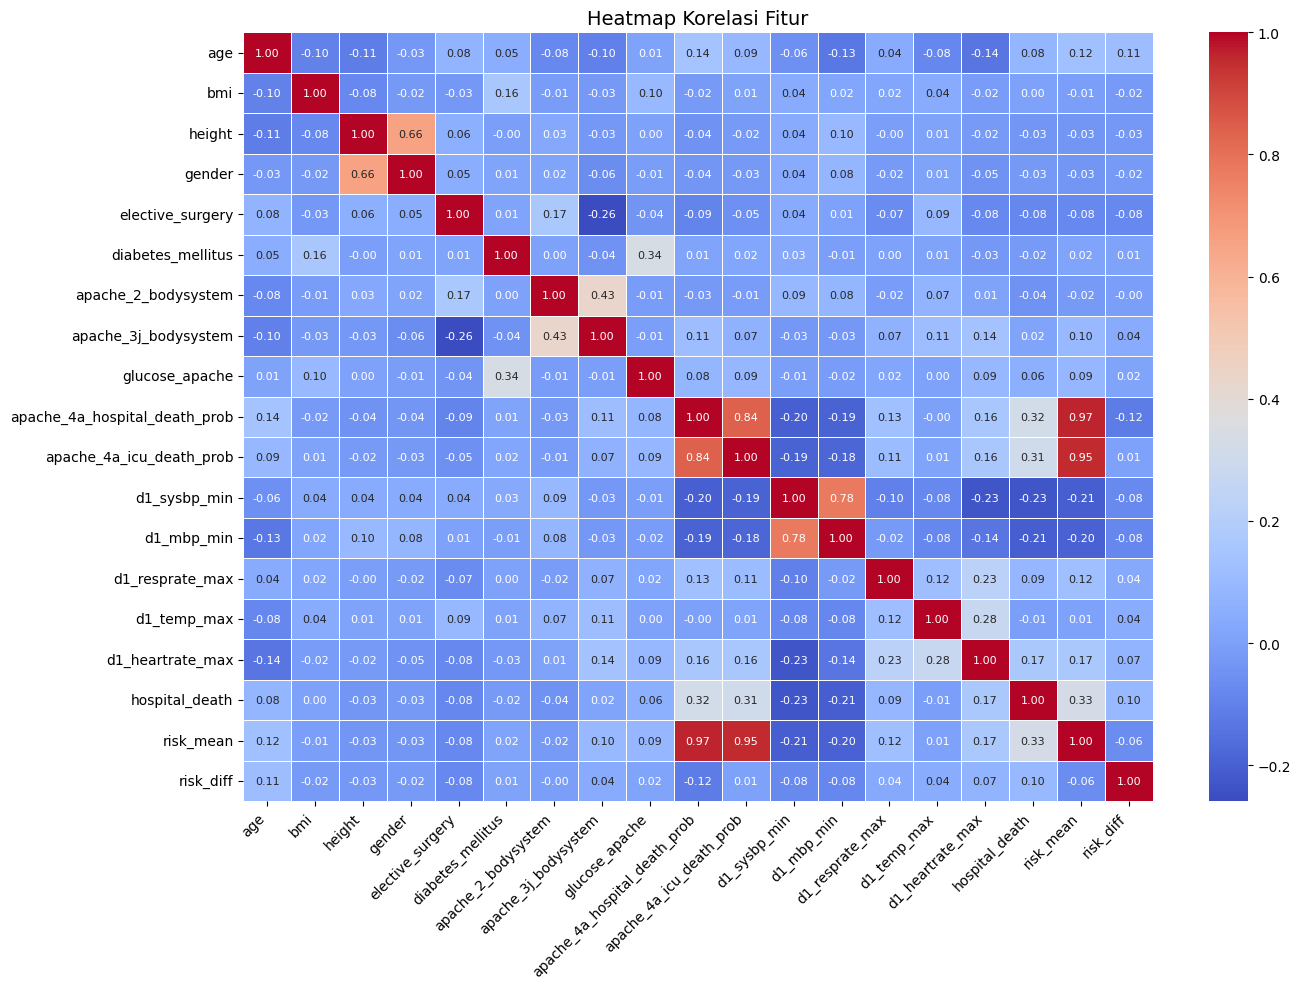

In [ ]:
# KORELASI ANTAR FITUR
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.title("Heatmap Korelasi Fitur", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 5. Data Splitting

Pada tahap ini dilakukan pembagian data menjadi data training dan data testing dengan tiga variasi rasio, yaitu:
*   70% training : 30% testing
*   80% training : 20% testing
*   90% training : 10% testing

Pembagian ini bertujuan untuk menguji konsistensi performa model pada berbagai skenario jumlah data latih. Parameter stratify=y digunakan agar proporsi kelas pada data training dan testing tetap seimbang sesuai distribusi data asli

In [ ]:
from sklearn.model_selection import train_test_split

# 70:30
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 80:20
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 90:10
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42, stratify=y)

print("Data splitting selesai untuk 3 rasio (70:30, 80:20, 90:10)")

Data splitting selesai untuk 3 rasio (70:30, 80:20, 90:10)


### 6. Model Building + SMOTE

Pada tahap ini dilakukan pembangunan model machine learning serta penanganan ketidakseimbangan data menggunakan metode SMOTE. SMOTE diterapkan hanya pada data training untuk meningkatkan jumlah data pada kelas minoritas tanpa menyebabkan kebocoran data (data leakage) ke data testing.

Selanjutnya, dibangun tiga model yang digunakan, yaitu Support Vector Machine (SVM), Extra Trees Classifier, dan XGBoost. Ketiga algoritma ini dipilih karena memiliki karakteristik yang berbeda dalam melakukan klasifikasi, sehingga dapat dibandingkan performanya. Tahap ini merupakan dasar sebelum dilakukan proses optimasi model melalui hyperparameter tuning pada tahap berikutnya.

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

# SMOTE (HANYA TRAIN SET)
smote = SMOTE(random_state=42)

X_train_70, y_train_70 = smote.fit_resample(X_train_70, y_train_70)
X_train_80, y_train_80 = smote.fit_resample(X_train_80, y_train_80)
X_train_90, y_train_90 = smote.fit_resample(X_train_90, y_train_90)

print("SMOTE applied on training sets only")

# MODEL BUILDING

# SVM
svm = SVC()

# Extra Trees
et = ExtraTreesClassifier(random_state=42)

# XGBoost
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

SMOTE applied on training sets only


### 7. Hyperparameter Tuning

Pada tahap ini dilakukan proses hyperparameter tuning untuk meningkatkan performa model menggunakan metode GridSearchCV. GridSearchCV bekerja dengan mencoba berbagai kombinasi parameter untuk setiap algoritma, kemudian memilih parameter terbaik berdasarkan hasil cross-validation. Parameter yang dituning antara lain:
*   SVM: parameter C dan gamma
*   Extra Trees: jumlah pohon (n_estimators), kedalaman pohon (max_depth), dan minimum split
*   XGBoost: jumlah estimator, kedalaman pohon, dan learning rate

Proses tuning dilakukan pada setiap variasi data splitting (70:30, 80:20, dan 90:10) untuk memastikan model memiliki performa optimal pada berbagai kondisi data.

In [ ]:
from sklearn.model_selection import GridSearchCV

# HYPERPARAMETER TUNING

# Parameter SVM
svm_param = {
    'C': [1, 10, 50],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']
}

# Parameter Extra Trees
et_param = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Parameter XGBoost
xgb_param = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

# ===== SVM =====
svm_70 = GridSearchCV(svm, svm_param, cv=3, n_jobs=-1).fit(X_train_70, y_train_70)
svm_80 = GridSearchCV(svm, svm_param, cv=3, n_jobs=-1).fit(X_train_80, y_train_80)
svm_90 = GridSearchCV(svm, svm_param, cv=3, n_jobs=-1).fit(X_train_90, y_train_90)

# ===== EXTRA TREES =====
et_70 = GridSearchCV(et, et_param, cv=3, n_jobs=-1)
et_70.fit(X_train_70, y_train_70)

et_80 = GridSearchCV(et, et_param, cv=3, n_jobs=-1)
et_80.fit(X_train_80, y_train_80)

et_90 = GridSearchCV(et, et_param, cv=3, n_jobs=-1)
et_90.fit(X_train_90, y_train_90)

# ===== XGBOOST =====
xgb_70 = GridSearchCV(xgb, xgb_param, cv=3, n_jobs=-1).fit(X_train_70, y_train_70)
xgb_80 = GridSearchCV(xgb, xgb_param, cv=3, n_jobs=-1).fit(X_train_80, y_train_80)
xgb_90 = GridSearchCV(xgb, xgb_param, cv=3, n_jobs=-1).fit(X_train_90, y_train_90)

print("Hyperparameter tuning selesai untuk semua model dan semua rasio split")

Hyperparameter tuning selesai untuk semua model dan semua rasio split


### 8. Model Evaluation

Pada tahap ini dilakukan evaluasi performa model menggunakan beberapa metrik klasifikasi, yaitu accuracy, precision, recall, dan F1-score. Selain itu, ditampilkan juga classification report dan confusion matrix untuk memberikan gambaran lebih detail mengenai hasil prediksi model terhadap masing-masing kelas.

Evaluasi dilakukan pada setiap algoritma (SVM, Extra Trees, dan XGBoost) serta pada setiap variasi data splitting (70:30, 80:20, dan 90:10) untuk mengetahui performa model secara menyeluruh

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# EVALUATION FUNCTION
results = []

def evaluate_model(name, y_true, y_pred, split):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{name} - Split {split}")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    results.append([name, split, acc, prec, rec, f1])

Algoritma SVM

In [ ]:
# ===== SVM =====
evaluate_model("SVM", y_test_70, svm_70.predict(X_test_70), "70:30")
evaluate_model("SVM", y_test_80, svm_80.predict(X_test_80), "80:20")
evaluate_model("SVM", y_test_90, svm_90.predict(X_test_90), "90:10")


SVM - Split 70:30
Accuracy : 0.8673333333333333
Precision: 0.275
Recall   : 0.3464566929133858
F1 Score : 0.30662020905923343

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1373
           1       0.28      0.35      0.31       127

    accuracy                           0.87      1500
   macro avg       0.61      0.63      0.62      1500
weighted avg       0.88      0.87      0.87      1500

Confusion Matrix:
[[1257  116]
 [  83   44]]

SVM - Split 80:20
Accuracy : 0.871
Precision: 0.3103448275862069
Recall   : 0.4235294117647059
F1 Score : 0.3582089552238806

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       915
           1       0.31      0.42      0.36        85

    accuracy                           0.87      1000
   macro avg       0.63      0.67      0.64      1000
weighted avg       0.89      0.87      0.88      1000



Algoritma Extra Trees Classifier

In [ ]:
# ===== EXTRA TREES =====
evaluate_model("ExtraTrees", y_test_70, et_70.predict(X_test_70), "70:30")
evaluate_model("ExtraTrees", y_test_80, et_80.predict(X_test_80), "80:20")
evaluate_model("ExtraTrees", y_test_90, et_90.predict(X_test_90), "90:10")


ExtraTrees - Split 70:30
Accuracy : 0.9013333333333333
Precision: 0.4117647058823529
Recall   : 0.3858267716535433
F1 Score : 0.3983739837398374

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1373
           1       0.41      0.39      0.40       127

    accuracy                           0.90      1500
   macro avg       0.68      0.67      0.67      1500
weighted avg       0.90      0.90      0.90      1500

Confusion Matrix:
[[1303   70]
 [  78   49]]

ExtraTrees - Split 80:20
Accuracy : 0.914
Precision: 0.4936708860759494
Recall   : 0.4588235294117647
F1 Score : 0.47560975609756095

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       915
           1       0.49      0.46      0.48        85

    accuracy                           0.91      1000
   macro avg       0.72      0.71      0.71      1000
weighted avg       0.91     

Algoritma XGBoost

In [ ]:
# ===== XGBOOST =====
evaluate_model("XGBoost", y_test_70, xgb_70.predict(X_test_70), "70:30")
evaluate_model("XGBoost", y_test_80, xgb_80.predict(X_test_80), "80:20")
evaluate_model("XGBoost", y_test_90, xgb_90.predict(X_test_90), "90:10")


XGBoost - Split 70:30
Accuracy : 0.9126666666666666
Precision: 0.4787234042553192
Recall   : 0.3543307086614173
F1 Score : 0.4072398190045249

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1373
           1       0.48      0.35      0.41       127

    accuracy                           0.91      1500
   macro avg       0.71      0.66      0.68      1500
weighted avg       0.90      0.91      0.91      1500

Confusion Matrix:
[[1324   49]
 [  82   45]]

XGBoost - Split 80:20
Accuracy : 0.913
Precision: 0.4838709677419355
Recall   : 0.35294117647058826
F1 Score : 0.40816326530612246

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       915
           1       0.48      0.35      0.41        85

    accuracy                           0.91      1000
   macro avg       0.71      0.66      0.68      1000
weighted avg       0.90      0.91

### 9. Model Comparison

Pada tahap ini dilakukan perbandingan performa model menggunakan tabel dan visualisasi grafik. Tabel digunakan untuk menampilkan nilai evaluasi setiap model secara rinci, sedangkan grafik batang digunakan untuk mempermudah interpretasi perbandingan akurasi antar model dan antar variasi data splitting.

Dari grafik yang dihasilkan, dapat terlihat bahwa model XGBoost memiliki performa tertinggi dibandingkan model lainnya, diikuti oleh SVM dan Extra Trees

In [ ]:
# TABEL PERBANDINGAN MODEL
result_df = pd.DataFrame(results, columns=["Model", "Split", "Accuracy", "Precision", "Recall", "F1 Score"])

print("\n===== PERBANDINGAN MODEL =====")
print(result_df)


===== PERBANDINGAN MODEL =====
        Model  Split  Accuracy  Precision    Recall  F1 Score
0         SVM  70:30  0.867333   0.275000  0.346457  0.306620
1         SVM  80:20  0.871000   0.310345  0.423529  0.358209
2         SVM  90:10  0.880000   0.312500  0.357143  0.333333
3  ExtraTrees  70:30  0.901333   0.411765  0.385827  0.398374
4  ExtraTrees  80:20  0.914000   0.493671  0.458824  0.475610
5  ExtraTrees  90:10  0.902000   0.405405  0.357143  0.379747
6     XGBoost  70:30  0.912667   0.478723  0.354331  0.407240
7     XGBoost  80:20  0.913000   0.483871  0.352941  0.408163
8     XGBoost  90:10  0.906000   0.419355  0.309524  0.356164


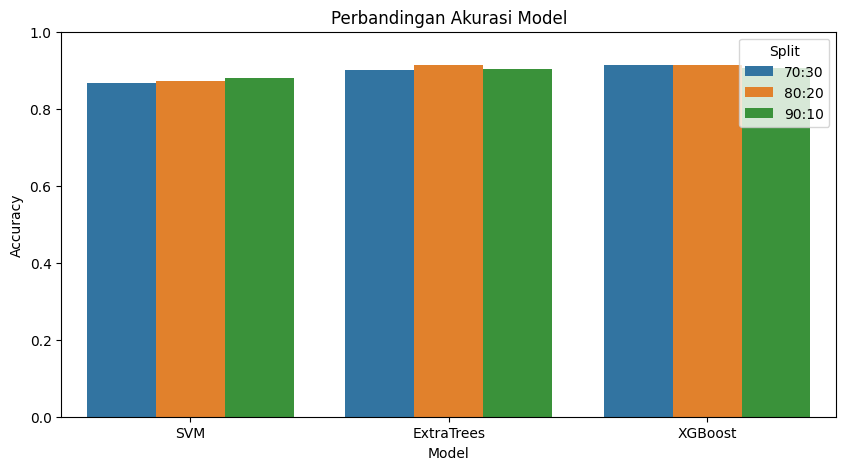

In [ ]:
# VISUALISASI PERBANDINGAN (BARPLOT)
plt.figure(figsize=(10,5))

sns.barplot(data=result_df, x="Model", y="Accuracy", hue="Split")

plt.title("Perbandingan Akurasi Model")
plt.ylim(0,1)
plt.legend(title="Split")
plt.show()

### 10. Implementasi Model (Inference)

Pada tahap ini dilakukan inference dengan menggunakan model yang telah dilatih untuk memprediksi kondisi pasien baru berdasarkan fitur seperti umur, BMI, glukosa, detak jantung, tekanan darah, dan probabilitas ICU, di mana data diproses dengan tahapan yang sama seperti training sebelum dimasukkan ke model (XGBoost, SVM, atau Extra Trees) untuk menghasilkan prediksi hidup atau meninggal beserta probabilitasnya.

In [ ]:
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# JUDUL
title = widgets.HTML("<h2 style='text-align:center;'>Prediksi Kematian Pasien ICU</h2>")
subtitle = widgets.HTML("<p style='text-align:center;'>Simulasi Inference Model Machine Learning</p>")

# INPUT USER
umur = widgets.IntText(description="Umur:", value=60)

gender = widgets.Dropdown(
    options=[("Male", 1), ("Female", 0)],
    description="Gender:"
)

bmi = widgets.FloatText(description="BMI:", value=25.0)
glukosa = widgets.FloatText(description="Glukosa:", value=150)
detak = widgets.IntText(description="Detak Jantung:", value=90)
tekanan = widgets.IntText(description="Tekanan Darah:", value=90)
icu_prob = widgets.FloatText(description="Prob ICU:", value=0.2)

input_box = widgets.VBox([
    widgets.HTML("<b>Input Data Pasien</b>"),
    umur,
    gender,
    bmi,
    glukosa,
    detak,
    tekanan,
    icu_prob
])

# MODEL + OUTPUT
model_choice = widgets.Dropdown(
    options=["XGBoost", "SVM", "Extra Trees"],
    description="Model:"
)

predict_btn = widgets.Button(
    description="Prediksi",
    button_style='success',
    layout=widgets.Layout(width='150px', height='40px')
)

output = widgets.Output()

control_box = widgets.VBox([
    widgets.HTML("<b>Pilih Model</b>"),
    model_choice,
    widgets.HTML("<br>"),
    predict_btn,
    widgets.HTML("<br><b>Hasil Prediksi</b>"),
    output
])

# LAYOUT
ui = widgets.HBox(
    [input_box, control_box],
    layout=widgets.Layout(justify_content='space-around')
)

display(title, subtitle, ui)

# FUNGSI PREDIKSI
def predict_fn(b):
    with output:
        output.clear_output()

        # DATA INPUT
        data = np.array([[
            umur.value,
            bmi.value,
            170,                # height
            gender.value,       # gender (FIXED)
            0,                  # elective_surgery
            0,                  # diabetes
            2,                  # apache_2
            3,                  # apache_3
            glukosa.value,
            icu_prob.value,
            icu_prob.value,
            tekanan.value,
            70,
            30,
            37,
            detak.value
        ]])

        # FEATURE ENGINEERING
        risk_mean = (data[:,9] + data[:,10]) / 2
        risk_diff = abs(data[:,9] - data[:,10])
        data = np.hstack((data, risk_mean.reshape(-1,1), risk_diff.reshape(-1,1)))

        # FIX WARNING (PAKAI DATAFRAME)
        data_df = pd.DataFrame(data, columns=X.columns)

        # SCALING
        data_scaled = scaler.transform(data_df)

        # PILIH MODEL
        if model_choice.value == "XGBoost":
            model = xgb_80.best_estimator_
        elif model_choice.value == "SVM":
            model = svm_80.best_estimator_
        else:
            model = et_80.best_estimator_

        # PREDIKSI
        pred = model.predict(data_scaled)

        try:
            prob = model.predict_proba(data_scaled)
            prob_mati = prob[0][1]
        except:
            prob_mati = None

        # OUTPUT
        if pred[0] == 1:
            display(HTML("<h3 style='color:red;'>🔴 Prediksi: MENINGGAL</h3>"))
        else:
            display(HTML("<h3 style='color:green;'>🟢 Prediksi: HIDUP</h3>"))

        if prob_mati is not None:
            display(HTML(f"<b>Probabilitas Meninggal: {prob_mati:.2f}</b>"))

# BUTTON ACTION
predict_btn.on_click(predict_fn)

HTML(value="<h2 style='text-align:center;'>Prediksi Kematian Pasien ICU</h2>")

HTML(value="<p style='text-align:center;'>Simulasi Inference Model Machine Learning</p>")

### 11. Ubah Model untuk Deploy ke Streamlit

In [38]:
import joblib

joblib.dump(xgb_80.best_estimator_, "model_xgb.pkl")
joblib.dump(svm_80.best_estimator_, "model_svm.pkl")
joblib.dump(et_80.best_estimator_, "model_et.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("File berhasil disimpan!")

File berhasil disimpan!


In [39]:
!pip install streamlit pyngrok

In [43]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import joblib

# =========================
# LOAD MODEL
# =========================
xgb = joblib.load("model_xgb.pkl")
svm = joblib.load("model_svm.pkl")
et = joblib.load("model_et.pkl")

scaler = joblib.load("scaler.pkl")
columns = joblib.load("columns.pkl")

# =========================
# TITLE
# =========================
st.title("🏥 Prediksi Kematian Pasien ICU")
st.write("Menggunakan 3 Model Machine Learning")

st.write("---")

# =========================
# INPUT USER
# =========================
st.subheader("📝 Input Data Pasien")

umur = st.number_input("Umur", value=60)
gender = st.selectbox("Gender", ["Male", "Female"])
bmi = st.number_input("BMI", value=25.0)
glukosa = st.number_input("Glukosa", value=150.0)
detak = st.number_input("Detak Jantung", value=90)
tekanan = st.number_input("Tekanan Darah", value=90)
icu_prob = st.number_input("Prob ICU", value=0.2)

st.write("---")

# =========================
# PREDIKSI
# =========================
if st.button("🔍 Prediksi"):

    gender_val = 1 if gender == "Male" else 0

    data = np.array([[
        umur, bmi, 170, gender_val, 0, 0, 2, 3,
        glukosa, icu_prob, icu_prob, tekanan,
        70, 30, 37, detak
    ]])

    # Feature engineering
    risk_mean = (data[:,9] + data[:,10]) / 2
    risk_diff = abs(data[:,9] - data[:,10])
    data = np.hstack((data, risk_mean.reshape(-1,1), risk_diff.reshape(-1,1)))

    df = pd.DataFrame(data, columns=columns)
    data_scaled = scaler.transform(df)

    # =========================
    # MODEL
    # =========================
    models = {
        "XGBoost": xgb,
        "SVM": svm,
        "Extra Trees": et
    }

    st.subheader("📊 Hasil Prediksi Model")

    results = []

    for name, model in models.items():
        pred = model.predict(data_scaled)[0]
        results.append(pred)

        if pred == 1:
            st.markdown(
                f"""
                <div style="
                    padding:15px;
                    border-radius:10px;
                    background-color:#3b0d0d;
                    color:white;
                    margin-bottom:10px;">
                    <b>{name}</b> → 🔴 Meninggal
                </div>
                """,
                unsafe_allow_html=True
            )
        else:
            st.markdown(
                f"""
                <div style="
                    padding:15px;
                    border-radius:10px;
                    background-color:#0d3b1f;
                    color:white;
                    margin-bottom:10px;">
                    <b>{name}</b> → 🟢 Hidup
                </div>
                """,
                unsafe_allow_html=True
            )

    # =========================
    # KESIMPULAN
    # =========================
    st.write("---")
    st.subheader("🧠 Kesimpulan")

    if sum(results) >= 2:
        st.error("Mayoritas model memprediksi: 🔴 MENINGGAL")
    else:
        st.success("Mayoritas model memprediksi: 🟢 HIDUP")

Overwriting app.py


In [50]:
from pyngrok import ngrok
ngrok.kill()

In [51]:
from pyngrok import ngrok

ngrok.set_auth_token("3ChARcFpLYaEIu7mb9wz4KdJgsR_j86TawGs6DEAZqzBa26s")

In [52]:
!streamlit run app.py &>/dev/null &
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://legged-overrun-stress.ngrok-free.dev" -> "http://localhost:8501">